In [1]:
#to start from root folder
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

In [2]:
#importing to first see if our ftns are working fine
import numpy as np
from src.color_spaces import rgb_to_lms, lms_to_rgb

In [3]:
# fake a tiny "image" — 1 pixel, some arbitrary RGB value
test_pixel = np.array([[[0.5, 0.2, 0.8]]])  # shape (1,1,3)

lms = rgb_to_lms(test_pixel)
back_to_rgb = lms_to_rgb(lms)

print(test_pixel)
print(back_to_rgb)

[[[0.5 0.2 0.8]]]
[[[0.5 0.2 0.8]]]


In [4]:
#success!

In [5]:
#let's test our simulation on a real image now, time for the test!!
from src.utils import load_image_rgb_normalized, save_image_rgb_normalized
from src.simulate import simulate_cvd, PROTANOPIA_MATRIX, TRITANOPIA_MATRIX, DEUTERANOPIA_MATRIX

In [6]:
img = load_image_rgb_normalized('D:/downloads/colorblind-accessibility/data/test_images/74_img.jpg')
simulated = simulate_cvd(img, PROTANOPIA_MATRIX)
save_image_rgb_normalized(simulated, 'D:/downloads/colorblind-accessibility/data/test_imagesprotanopia_output.jpg')

In [7]:
#gonna run some checks to see file save
import os

In [8]:
print(os.getcwd())  # is this the project root, or somewhere else?
print(os.path.exists('data/test_images'))  # does the path even resolve from here?

d:\downloads\colorblind-accessibility\notebooks
False


In [9]:
#we'll be using absolute paths for file saves to avoid mishaps
#visualizing our experiment
import matplotlib.pyplot as plt

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.1980263420688228..1.0001728277936046].


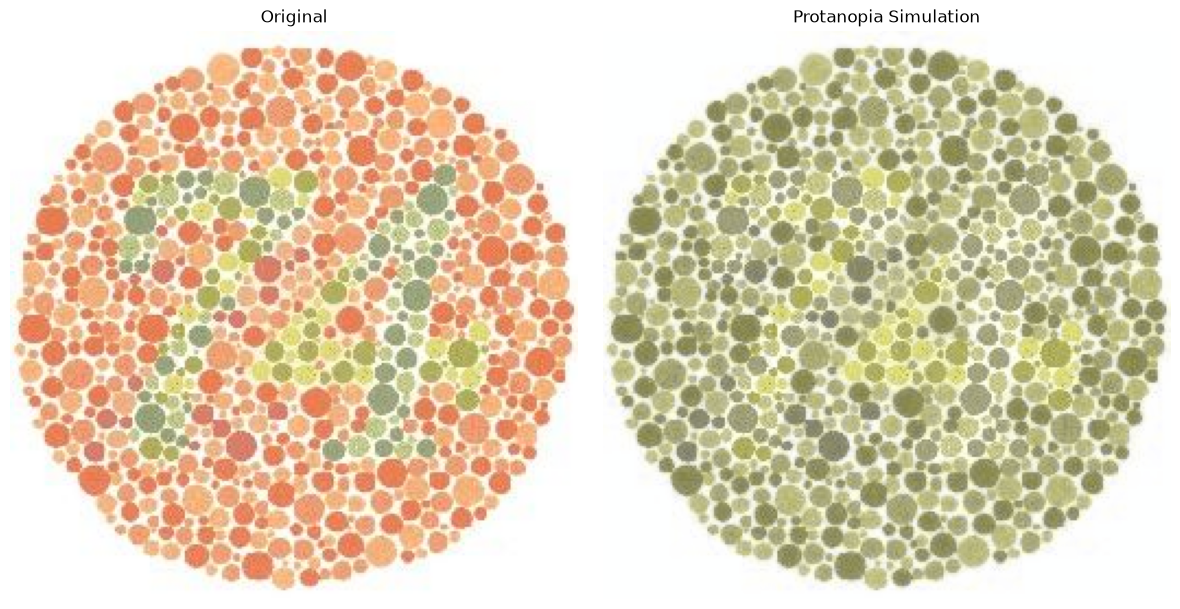

In [10]:
#comparing protanopia with original image
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img)
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(simulated)
axes[1].set_title('Protanopia Simulation')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [11]:
img = load_image_rgb_normalized('D:/downloads/colorblind-accessibility/data/test_images/74_img.jpg')
simulated = simulate_cvd(img, DEUTERANOPIA_MATRIX)
save_image_rgb_normalized(simulated, 'D:/downloads/colorblind-accessibility/data/test_imagesdeuteranopia_output.jpg')

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.1852168089041222..1.0025403257290544].


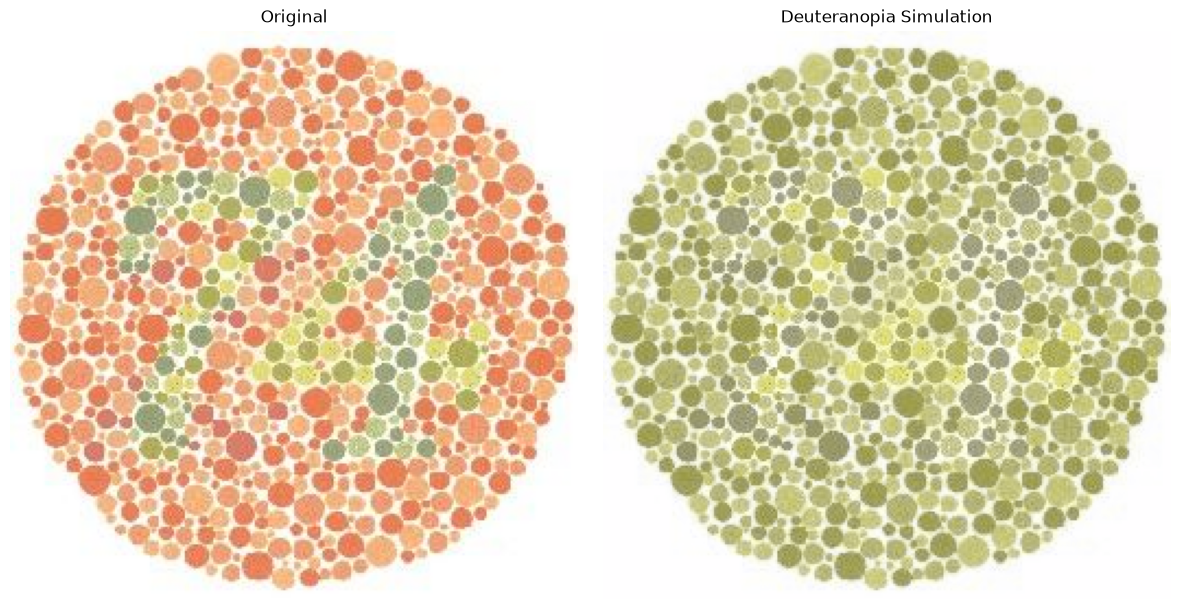

In [12]:
#comparing deuteranopia with original image
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img)
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(simulated)
axes[1].set_title('Deuteranopia Simulation')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [13]:
img = load_image_rgb_normalized('D:/downloads/colorblind-accessibility/data/test_images/74_img.jpg')
simulated = simulate_cvd(img, TRITANOPIA_MATRIX)
save_image_rgb_normalized(simulated, 'D:/downloads/colorblind-accessibility/data/test_imagestritanopia_output.jpg')

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.425725899390536..1.3424562997995648].


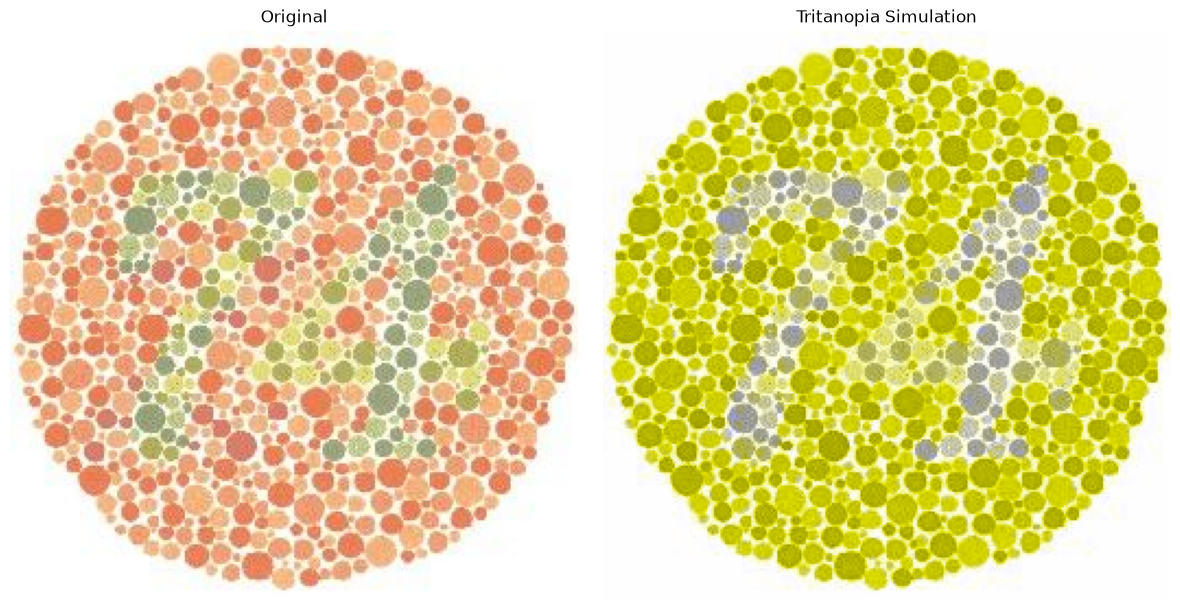

In [14]:
#comparing tritanopia with original image
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img)
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(simulated)
axes[1].set_title('Tritanopia Simulation')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [15]:
#tritanopia shouldn't be changing the red/orange this drastically. since we've been implementing the simplified version of Brettel method, this seems to be expected.

In [16]:
#further diagnosing by isolating orange

orange = np.array([[[1.0, 0.65, 0.0]]])  # roughly orange, normalized

lms = rgb_to_lms(orange)
print("LMS:", lms)

sim_lms = lms @ TRITANOPIA_MATRIX.T
print("Simulated LMS:", sim_lms)

sim_rgb = lms_to_rgb(sim_lms)
print("Simulated RGB (unclipped):", sim_rgb)

LMS: [[[46.167865   21.10666     0.14975745]]]
Simulated LMS: [[[46.167865   21.10666    -1.36972265]]]
Simulated RGB (unclipped): [[[ 0.82264466  0.82263529 -1.05377678]]]


In [17]:
#naive clipping is destroying the hue. simplified projection pushes S so far negative that clipping wipes it out entirely instead of just dimming it.